## Notebook for Metrics and correlation analysis

In [8]:
import numpy as np
import pandas as pd

def compute_motion_metrics(df_hand, hand_label="Left", fps=30):
    df = df_hand.copy()

    # real time delta in seconds
    df["dt"] = df["frame_diff"] / fps

    # Avoid division by zero or invalid dt
    df = df[df["dt"] > 0]
    
    # temporary here for test
    df["disp_filtered"] = np.where(
            df["disp"].isna(), 
            np.nan,  # keep NaN as NaN
            np.where(df["disp"] > 2.0, df["disp"], 0.0)
        )

    # velocity (px/s)
    df["velocity"] = df["disp_filtered"] / df["dt"]

    # acceleration (px/s^2)
    df["accel"] = df["velocity"].diff() / df["dt"]

    # jerk (px/s^3)
    df["jerk"] = df["accel"].diff() / df["dt"]

    # RMS values for smoothness
    std_speed = df['velocity'].std(skipna=True)
    mean_speed = df['velocity'].mean(skipna=True)
    rms_accel = np.sqrt((df["accel"]**2).mean())
    rms_jerk = np.sqrt((df["jerk"]**2).mean())

    # tremor approximation (since I sample at 10Hz likely not capturing high freq tremor)
    df["vel_smooth"] = df["velocity"].rolling(7, center=True, min_periods=1).mean()
    tremor_energy = ((df["velocity"] - df["vel_smooth"])**2).mean()

    # duty cycle (was the hand active vs idle?)
    velocity_threshold = 20.0  # px/s
    movement_time = (df['velocity'] > velocity_threshold).multiply(df['dt']).sum()
    total_time = df['dt'].sum()
    duty_cycle = movement_time / total_time


    df_metrics = pd.DataFrame({
        f"total_path_{hand_label.lower()}": [df["disp_filtered"].sum()],
        f"mean_speed_{hand_label.lower()}": [mean_speed],
        f"std_speed_{hand_label.lower()}": [std_speed],
        f"rms_accel_{hand_label.lower()}": [rms_accel],
        f"rms_jerk_{hand_label.lower()}": [rms_jerk],
        f"tremor_energy_{hand_label.lower()}": [tremor_energy],
        f"duty_cycle_{hand_label.lower()}": [duty_cycle],
    })
    
    return df_metrics


def compute_extended_hand_metrics(df_hand, hand_label="Left", fps=30, velocity_threshold=20.0):
    """
    Compute extended surgical skill metrics for a single hand trajectory.
    
    Parameters
    ----------
    df_hand : pd.DataFrame
        Must include: 'frame', 'disp_filtered', 'cx_smooth', 'cy_smooth'
    hand_label : str
        Name of the hand ("Left" or "Right")
    fps : int
        Original video FPS
    velocity_threshold : float
        Threshold (px/sec) for defining active movement
    
    Returns
    -------
    pd.DataFrame
        Single-row DataFrame with extended skill metrics
    """
    df = df_hand.copy().sort_values("frame")

    # --- Compute dt ---
    df['frame_diff'] = df['frame'].diff().fillna(1)
    df['dt'] = df['frame_diff'] / fps

    # --- Velocity & acceleration ---
    df['velocity'] = df['disp_filtered'] / df['dt'].replace(0, np.nan)
    df['accel'] = df['velocity'].diff() / df['dt'].replace(0, np.nan)

    # --- Economy of Motion (path, curvature) ---
    total_path = df['disp_filtered'].sum()

    dx = np.diff(df['cx_smooth'].ffill())
    dy = np.diff(df['cy_smooth'].ffill())
    path_vec = np.vstack([dx, dy]).T

    # Displacement magnitude
    #disp = np.sqrt(dx**2 + dy**2)
    disp = df['disp_filtered'].values[1:]  # align with path_vec

    # Remove vectors caused by tracking jitter
    MIN_MOVE = 5  # tune between 3–6 depending on dataset
    valid = disp > MIN_MOVE
    path_vec = path_vec[valid]

    if len(path_vec) > 1:
        angles = np.arctan2(path_vec[1:,1], path_vec[1:,0]) - np.arctan2(path_vec[:-1,1], path_vec[:-1,0])
        angles = np.mod(angles + np.pi, 2*np.pi) - np.pi
        mean_abs_angle_change = np.mean(np.abs(angles))
        num_reversals = np.sum(np.diff(np.sign(angles)) != 0)  # rough reversal count
    else:
        mean_abs_angle_change = 0
        num_reversals = 0

    # --- Efficiency ---
    duration = df['dt'].sum()
    mean_velocity = df['velocity'].mean(skipna=True)
    rms_accel = np.sqrt((df['accel']**2).mean(skipna=True))
    efficiency = total_path / duration if duration > 0 else np.nan

    # --- Duty cycle: time fraction moving ---
    movement_time = (df['velocity'] > velocity_threshold).multiply(df['dt']).sum()
    duty_cycle = movement_time / duration if duration > 0 else np.nan

    # --- Tremor / micro-movements ---
    stationary_mask = df['velocity'] < velocity_threshold
    tremor_rms = np.sqrt((df.loc[stationary_mask, 'velocity']**2).mean()) if stationary_mask.any() else 0

    # --- Movement intermittency ratio ---
    moving = df['velocity'] > velocity_threshold
    if moving.any():
        intermittency_ratio = moving.astype(int).diff().abs().sum() / len(moving)
    else:
        intermittency_ratio = 0

    # intidicator for fraction of frames tracked
    tracking_fraction = df['frame'].nunique() / (df['frame'].max() - df['frame'].min() + 1) * 3 # 10 -> 30 fps
    adjusted_total_path = total_path / tracking_fraction if tracking_fraction > 0 else np.nan


    # --- Build single-row DataFrame ---
    metrics = pd.DataFrame([{
        f"total_path_{hand_label.lower()}": total_path,
        f"total_duration_{hand_label.lower()}": duration,
        #f"tracking_fraction_{hand_label.lower()}": tracking_fraction,
        #f"adjusted_total_path_{hand_label.lower()}": adjusted_total_path,
        f"mean_velocity_{hand_label.lower()}": mean_velocity,
        f"rms_accel_{hand_label.lower()}": rms_accel,
        f"efficiency_{hand_label.lower()}": efficiency,
        f"duty_cycle_{hand_label.lower()}": duty_cycle,
        f"tremor_rms_{hand_label.lower()}": tremor_rms,
        f"mean_abs_angle_change_{hand_label.lower()}": mean_abs_angle_change,
        f"num_reversals_{hand_label.lower()}": num_reversals,
        f"intermittency_ratio_{hand_label.lower()}": intermittency_ratio
    }])

    return metrics



def compute_bimanual_dexterity(df_left, df_right, fps=30, velocity_threshold=20):
    """
    Compute bimanual dexterity metrics:
    - Inter-hand coordination via velocity correlation
    - Stability of inter-hand distance
    - Overlap of movement activity (duty cycle synchrony)

    Returns a single-row DataFrame.
    """

    # Require overlapping frames for comparison
    df = pd.merge(
        df_left[["frame", "disp_filtered"]],
        df_right[["frame", "disp_filtered"]],
        on="frame",
        how="inner",
        suffixes=("_L", "_R")
    ).copy()

    if len(df) < 5:
        return pd.DataFrame([{
            "velocity_corr": np.nan,
            "interhand_dist_mean": np.nan,
            "interhand_dist_std": np.nan,
            "movement_overlap_ratio": np.nan,
        }])

    # Compute dt (frame spacing may be irregular)
    df["frame_diff"] = df["frame"].diff()
    df["dt"] = df["frame_diff"] / fps
    df = df[df["dt"] > 0]

    # Compute velocities (px/sec)
    df["vel_L"] = df["disp_filtered_L"] / df["dt"]
    df["vel_R"] = df["disp_filtered_R"] / df["dt"]

    # --- Velocity Correlation (Coordination) ---
    if df["vel_L"].std() > 1e-6 and df["vel_R"].std() > 1e-6:
        velocity_corr = df["vel_L"].corr(df["vel_R"])
    else:
        velocity_corr = np.nan
    
    # --- velocity corrrelation but only when both hands are moving ---
    moving_mask = (df["vel_L"] > velocity_threshold) & (df["vel_R"] > velocity_threshold)
    if moving_mask.sum() >= 5:
        if df.loc[moving_mask, "vel_L"].std() > 1e-6 and df.loc[moving_mask, "vel_R"].std() > 1e-6:
            velocity_corr_moving = df.loc[moving_mask, "vel_L"].corr(df.loc[moving_mask, "vel_R"])
        else:
            velocity_corr_moving = np.nan

    # --- Inter-Hand Distance (Spatial Coordination) ---
    # Need smoothed palm center coordinates
    if "cx_smooth" in df_left.columns:
        merged_xy = pd.merge(
            df_left[["frame", "cx_smooth", "cy_smooth"]],
            df_right[["frame", "cx_smooth", "cy_smooth"]],
            on="frame",
            how="inner",
            suffixes=("_L", "_R")
        )
        merged_xy["dist"] = np.sqrt(
            (merged_xy["cx_smooth_L"] - merged_xy["cx_smooth_R"])**2 +
            (merged_xy["cy_smooth_L"] - merged_xy["cy_smooth_R"])**2
        )
        interhand_dist_mean = merged_xy["dist"].mean()
        interhand_dist_std = merged_xy["dist"].std()
    else:
        interhand_dist_mean = np.nan
        interhand_dist_std = np.nan

    # --- Movement Overlap (Bimanual Duty Cycle Synchrony) ---
    moving_L = df["vel_L"] > velocity_threshold
    moving_R = df["vel_R"] > velocity_threshold
    movement_overlap_ratio = (moving_L & moving_R).mean()

    # Inter-hand distance coefficient of variation
    interhand_dist_cv = interhand_dist_std / interhand_dist_mean if interhand_dist_mean>0 else np.nan

    # RMS of distance change (stability of spacing)
    interhand_dist_change_rms = np.sqrt(np.mean(np.diff(merged_xy["dist"])**2))

    # Velocity ratio
    vel_ratio = df["vel_L"].mean() / df["vel_R"].mean() if df["vel_R"].mean()>0 else np.nan


    # Return in a one-row dataframe
    return pd.DataFrame([{
        "velocity_corr": velocity_corr,
        "velocity_corr_moving": velocity_corr_moving,
        "interhand_dist_mean": interhand_dist_mean,
        "interhand_dist_std": interhand_dist_std,
        "movement_overlap_ratio": movement_overlap_ratio,
        "interhand_dist_cv": interhand_dist_cv,
        "interhand_dist_change_rms": interhand_dist_change_rms,
        "velocity_ratio": vel_ratio
    }])


In [2]:
import os
import pandas as pd
from scipy import stats
from tqdm import tqdm
import os
import pandas as pd
from scipy import stats
from tqdm import tqdm
import inspect

def analyze_metrics_vs_grs(
    processed_dir: str,
    ratings_csv: str,
    metric_func,
    score_col = "GRS_Total",
    fps: int = 30,
    correlation = "pearson",
    end = "processed.pkl"
):
    """
    Compute motion metrics (single-hand or bimanual) for each processed file
    and correlate with GRS ratings.

    Behavior:
    - If metric_func expects (df_hand, hand_label, fps), runs per-hand and merges.
    - If metric_func does NOT include 'hand_label' in its arguments,
      it is assumed to be a bimanual metric function and is called as:
        metric_func(df_left, df_right, fps)
    """

    # Check function signature to determine mode
    params = inspect.signature(metric_func).parameters
    single_hand_mode = "hand_label" in params

    processed_files = sorted([
        f for f in os.listdir(processed_dir)
        if f.endswith(end)
    ])

    df_ratings = pd.read_csv(ratings_csv)
    df_metrics = pd.DataFrame()

    for df_name in tqdm(processed_files):
        if "2024-01-17_17-09-36" in df_name or "2024-01-17_18-24-28" in df_name or "2024-01-17_18-43-42" in df_name:
            continue
        df = pd.read_pickle(os.path.join(processed_dir, df_name))

        df_left = df[df['hand_label'] == 'Left']
        df_right = df[df['hand_label'] == 'Right']

        if single_hand_mode:
            # Expected form: metric_func(df_hand, hand_label, fps)
            metrics_left = metric_func(df_left, hand_label="Left", fps=fps)
            metrics_right = metric_func(df_right, hand_label="Right", fps=fps)
            metrics = pd.concat([metrics_left, metrics_right], axis=1)

        else:
            # Expected form: metric_func(df_left, df_right, fps)
            metrics = metric_func(df_left, df_right, fps=fps)

        metrics["file"] = df_name
        df_metrics = pd.concat([df_metrics, metrics], ignore_index=True)

    # --- Merge Motion Metrics with Ratings ---
    df_full = pd.concat([df_ratings.reset_index(drop=True),
                         df_metrics.reset_index(drop=True)], axis=1)

    # --- Compute correlations vs GRS ---
    correlations = {}
    for col in df_metrics.columns:
        if col == "file":
            continue
        if df_full[col].isna().all():
            continue
        
        if correlation == "pearson":
            r, p = stats.pearsonr(df_full[score_col], df_full[col])
        elif correlation == "spearman":
            r, p = stats.spearmanr(df_full[score_col], df_full[col])
        correlations[col] = {"correlation": r, "p_value": p}

    return df_full, correlations


import pandas as pd
import numpy as np

def correlated_metrics(df_metrics: pd.DataFrame, correlations: dict, threshold: float = 0.3):
    """
    Compute pairwise correlations between metrics that correlate with GRS above a threshold.

    Parameters
    ----------
    df_metrics : pd.DataFrame
        DataFrame of motion metrics (columns = metrics, rows = files)
    correlations : dict
        Dictionary of correlations vs GRS, as returned by analyze_metrics_vs_grs
        Format: {metric_name: {'correlation': r, 'p_value': p}}
    threshold : float
        Minimum absolute correlation with GRS to include metric

    Returns
    -------
    df_pairwise_corr : pd.DataFrame
        DataFrame of pairwise Pearson correlations between selected metrics
    selected_metrics : list
        List of metric names included (those with |r| > threshold)
    """

    # --- Step 1: select metrics that correlate with GRS above threshold ---
    selected_metrics = [
        m for m, val in correlations.items()
        if abs(val['correlation']) > threshold
    ]

    if len(selected_metrics) < 2:
        print("Not enough metrics meet the correlation threshold.")
        return pd.DataFrame(), selected_metrics

    # --- Step 2: compute pairwise correlations between selected metrics ---
    df_pairwise_corr = df_metrics[selected_metrics].corr(method='pearson')

    return df_pairwise_corr, selected_metrics


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_correlations(correlations_dict, title="Correlation with GRS_Total"):
    """
    Plot correlations as a bar chart with correlation values on top.
    
    Parameters
    ----------
    correlations_dict : dict
        Dictionary of correlations, format: {metric_name: {'correlation': r, 'p_value': p}}
    title : str
        Plot title
    """
    metrics = list(correlations_dict.keys())
    corrs = [v['correlation'] for v in correlations_dict.values()]
    pvals = [v['p_value'] for v in correlations_dict.values()]

    plt.figure(figsize=(10, 6))
    plt.bar(metrics, corrs, color='skyblue')
    plt.ylabel("Pearson Correlation with GRS_Total")
    plt.title(title)
    
    # Show correlation and p-value on top of bars
    for i, (r, p) in enumerate(zip(corrs, pvals)):
        plt.text(i, r, f"{r:.2f}\n(p={p:.2g})", ha='center', va='bottom' if r>=0 else 'top', fontsize=8)
    
    plt.xticks(rotation=90)
    plt.grid(axis='y')
    plt.ylim(-0.8, 0.8)
    plt.show()

def boxplot_metrics(df_metrics: pd.DataFrame, metrics: list):
    """
    Create boxplots for specified metrics.
    
    Parameters
    ----------
    df_metrics : pd.DataFrame
        DataFrame containing motion metrics
    metrics : list
        List of metric names to plot
    """
    plt.figure(figsize=(12, 6))
    plt.suptitle("Boxplots of Selected Motion Metrics", fontsize=16)
    for metric in metrics:
        plt.subplot(2, 4, metrics.index(metric)+1)
        plt.boxplot(df_metrics[metric].dropna(), vert=True)
        plt.title(f"{metric}")
        plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

In [ ]:
df_metrics0, correlations = analyze_metrics_vs_grs(
    processed_dir="processed_dataframes",
    ratings_csv="averaged_ratings.csv",
    metric_func=compute_motion_metrics,
    fps=30,
    correlation="spearman"
)

  0%|          | 1/258 [00:00<02:30,  1.71it/s]Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10a5cd4b0>>
Traceback (most recent call last):
  File "/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
  5%|▍         | 12/258 [00:11<06:49,  1.67s/it]

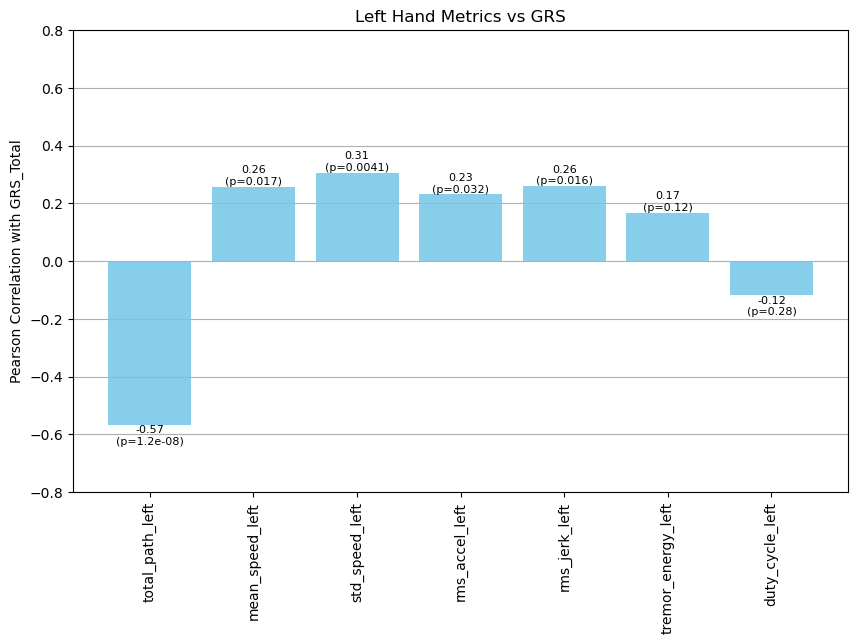

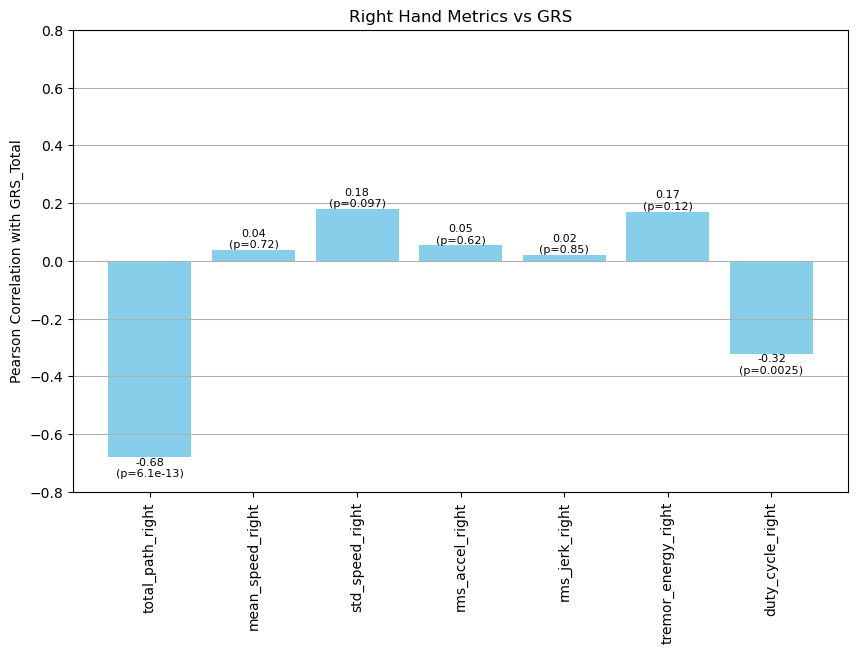

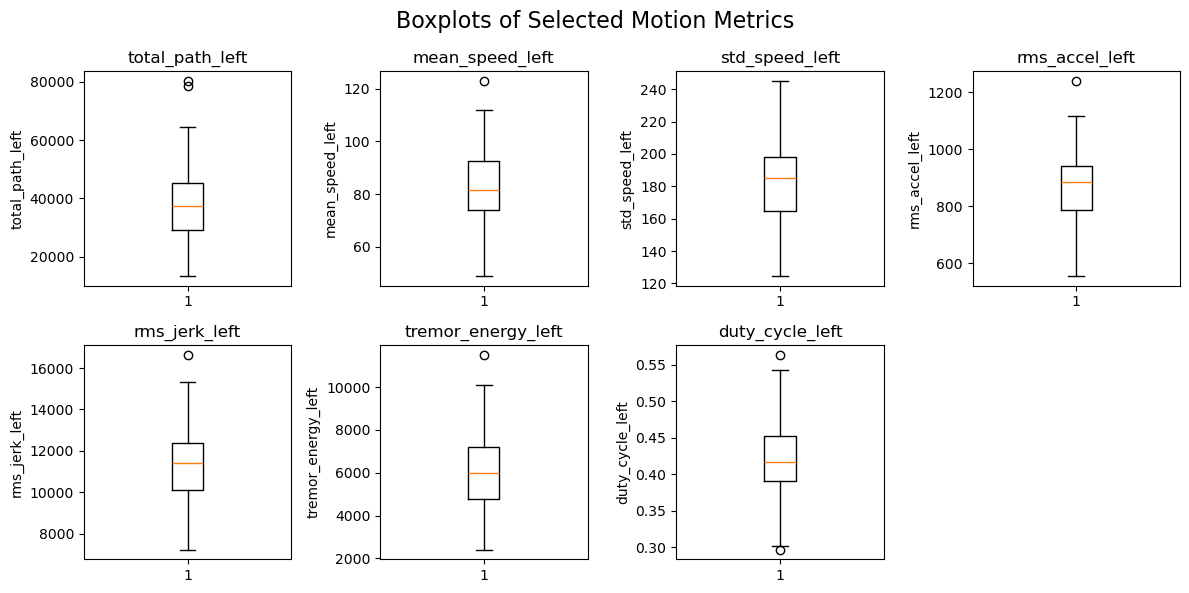

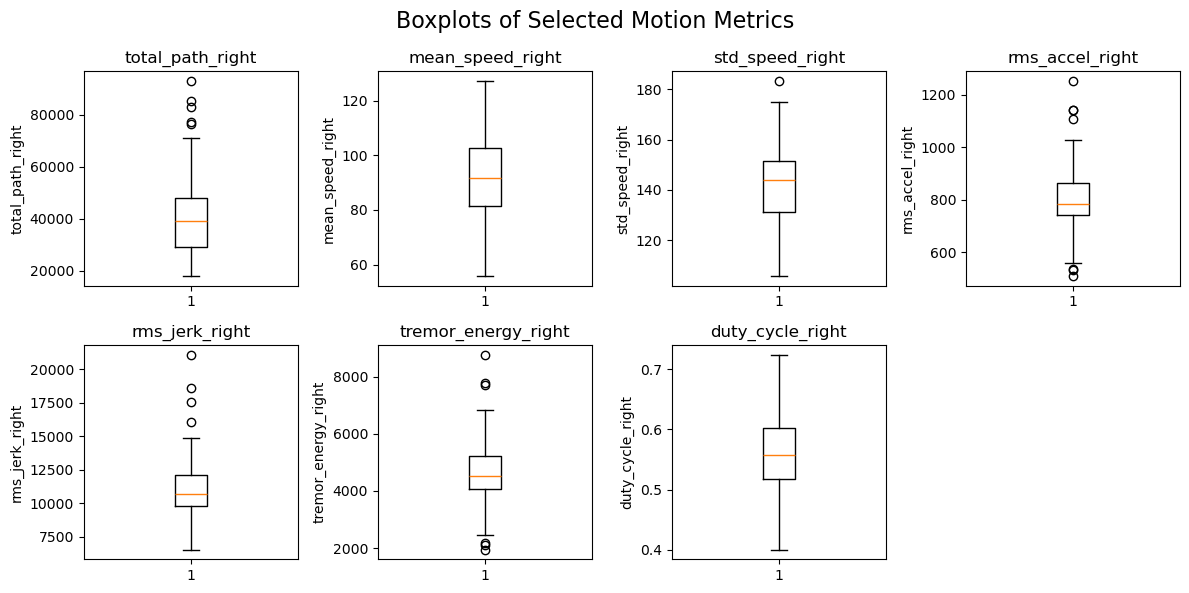

In [7]:
# Left-hand plot
left_metrics = [c for c in df_metrics0.columns if c.endswith("_left")]
left_corr = {k: v for k, v in correlations.items() if k in left_metrics}
plot_metric_correlations(left_corr, title="Left Hand Metrics vs GRS")

# Right-hand plot
right_metrics = [c for c in df_metrics0.columns if c.endswith("_right")]
right_corr = {k: v for k, v in correlations.items() if k in right_metrics}
plot_metric_correlations(right_corr, title="Right Hand Metrics vs GRS")

boxplot_metrics(df_metrics0, left_metrics)
boxplot_metrics(df_metrics0, right_metrics)

In [22]:
df_pairwise_corr_l, _ = correlated_metrics(
    df_metrics0[left_metrics], 
    left_corr, 
    threshold=0.3
)

df_pairwise_corr_r, _ = correlated_metrics(
    df_metrics0[right_metrics], 
    right_corr, 
    threshold=0.3
)

print("Left Hand Pairwise Correlations:\n", df_pairwise_corr_l, "\n")
print("Right Hand Pairwise Correlations:\n", df_pairwise_corr_r)


NameError: name 'df_metrics0' is not defined

In [13]:
df_metrics, correlations = analyze_metrics_vs_grs(
    processed_dir="processed_dataframes",
    ratings_csv="averaged_ratings.csv",
    metric_func=compute_extended_hand_metrics,
    fps=30,
    correlation="spearman",
    end = "10fps_processed.pkl"
)

  0%|          | 0/86 [00:00<?, ?it/s]

100%|██████████| 86/86 [00:42<00:00,  2.01it/s]


In [93]:
df_metrics.sort_values(by="tracking_fraction_right")[['Participant Number', 'Case_Number', 'tracking_fraction_left', 'tracking_fraction_right']]

,Participant Number,Case_Number,tracking_fraction_left,tracking_fraction_right
60,21,2,0.660929,0.513281
72,25,2,0.753165,0.568646
40,14,2,0.563831,0.612593
41,14,3,0.831967,0.623770
21,8,1,0.823753,0.641945
...,...,...,...,...
17,6,3,0.930452,0.852968
2,1,3,0.746926,0.857143
4,2,2,0.870397,0.865721
54,19,1,0.850755,0.879577


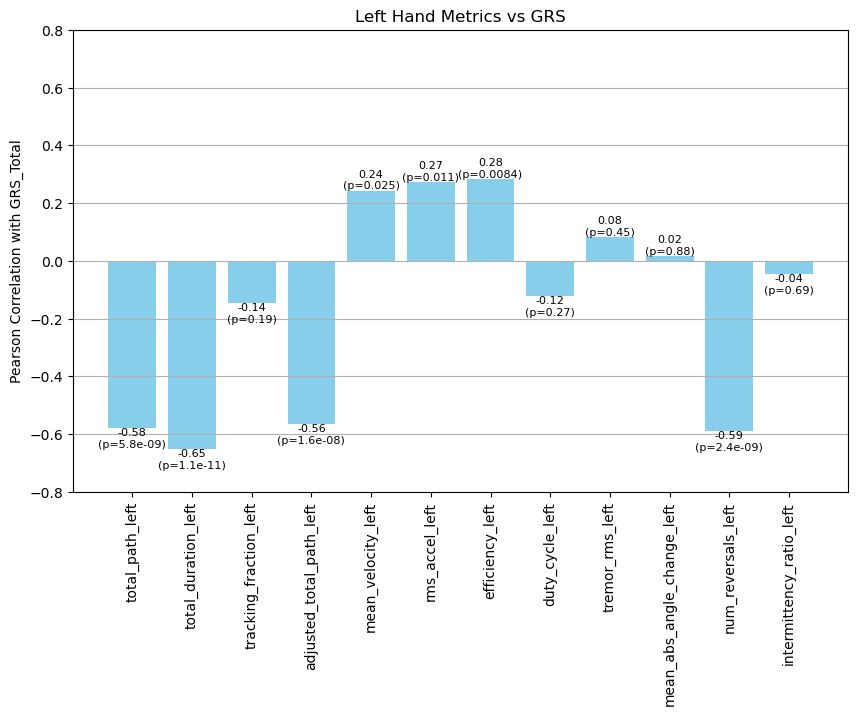

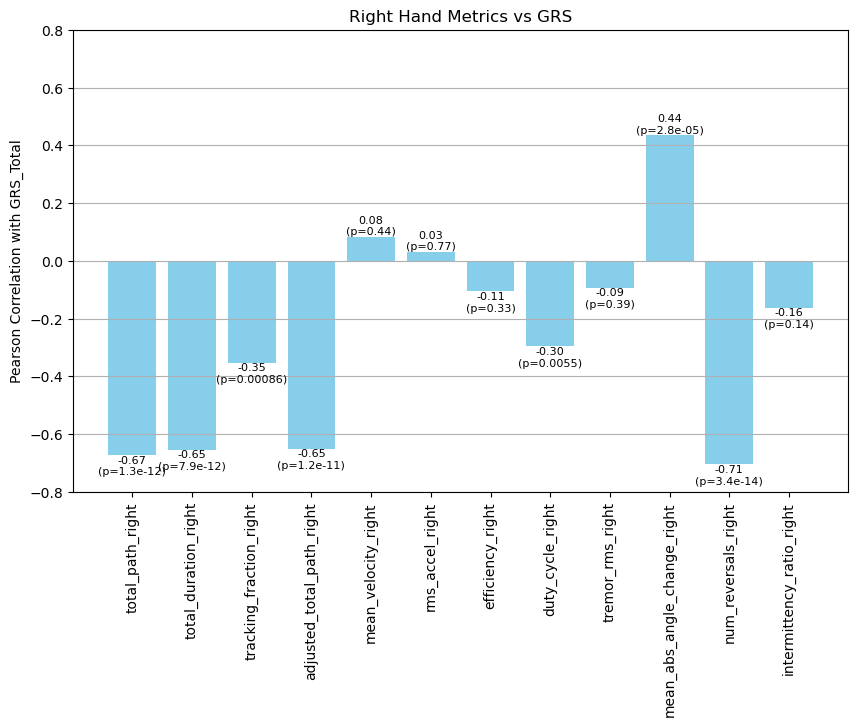

ValueError: num must be an integer with 1 <= num <= 8, not 9

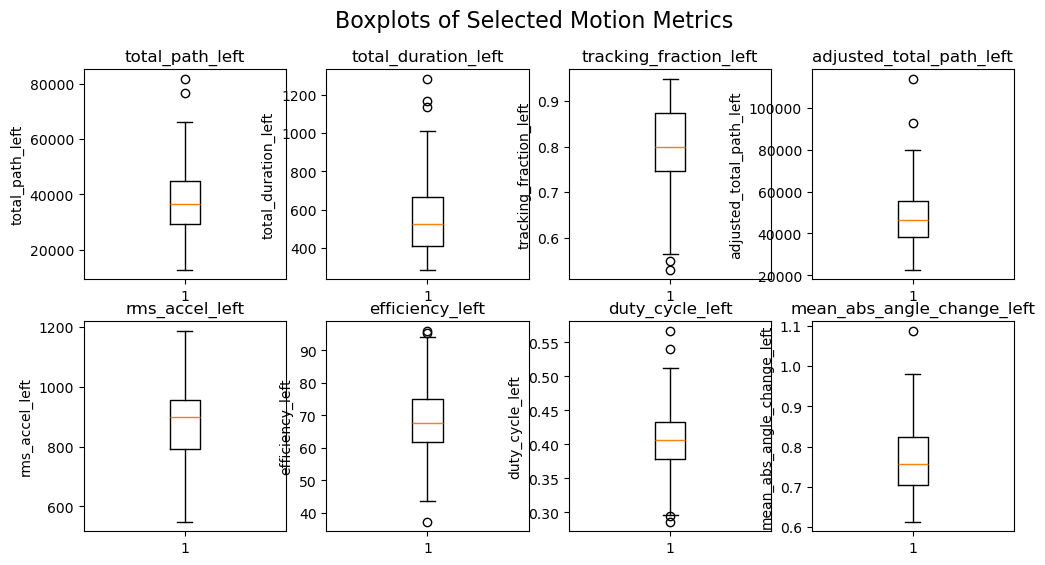

In [10]:

# Left-hand plot
left_metrics = [c for c in df_metrics.columns if c.endswith("_left")]
left_corr = {k: v for k, v in correlations.items() if k in left_metrics}
plot_metric_correlations(left_corr, title="Left Hand Metrics vs GRS")

# Right-hand plot
right_metrics = [c for c in df_metrics.columns if c.endswith("_right")]
right_corr = {k: v for k, v in correlations.items() if k in right_metrics}
plot_metric_correlations(right_corr, title="Right Hand Metrics vs GRS")

left_metrics.remove('tremor_rms_left')
left_metrics.remove('mean_velocity_left')
right_metrics.remove('tremor_rms_right')
right_metrics.remove('mean_velocity_right')
boxplot_metrics(df_metrics, left_metrics)
boxplot_metrics(df_metrics, right_metrics)

In [16]:
df_metrics, correlations = analyze_metrics_vs_grs(
    processed_dir="processed_dataframes",
    ratings_csv="merged_scores.csv",
    score_col='QRS_Overal',
    metric_func=compute_extended_hand_metrics,
    fps=30,
    correlation="spearman",
    end = "10fps_processed.pkl"
)


  0%|          | 0/86 [00:00<?, ?it/s]

100%|██████████| 86/86 [00:32<00:00,  2.61it/s]


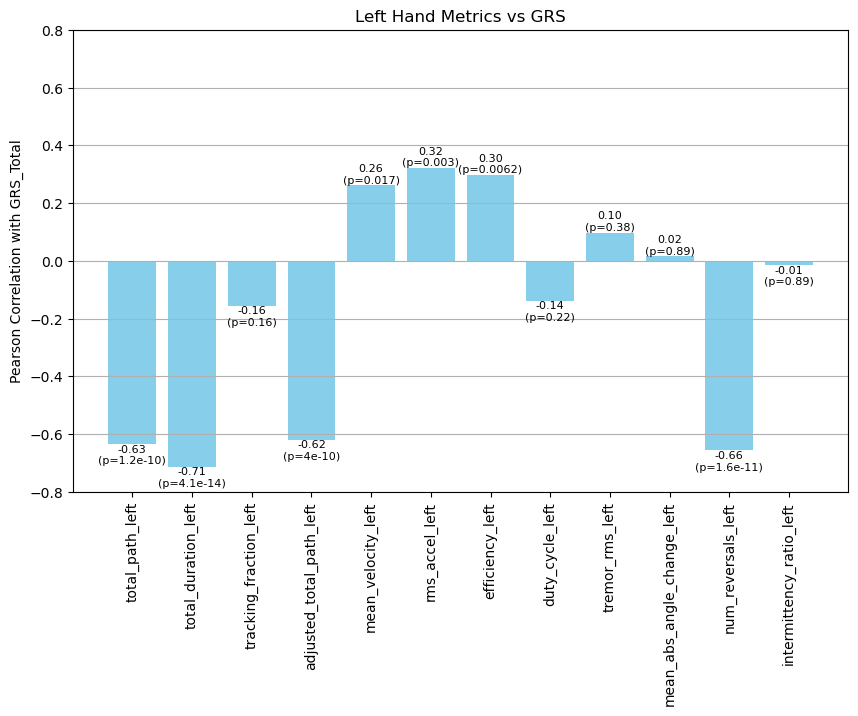

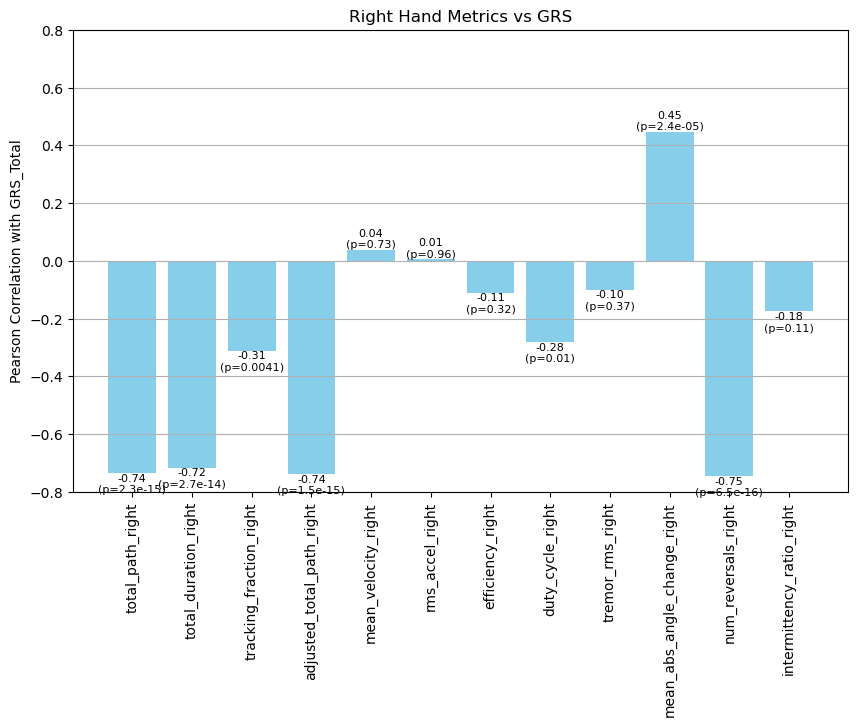

ValueError: num must be an integer with 1 <= num <= 8, not 9

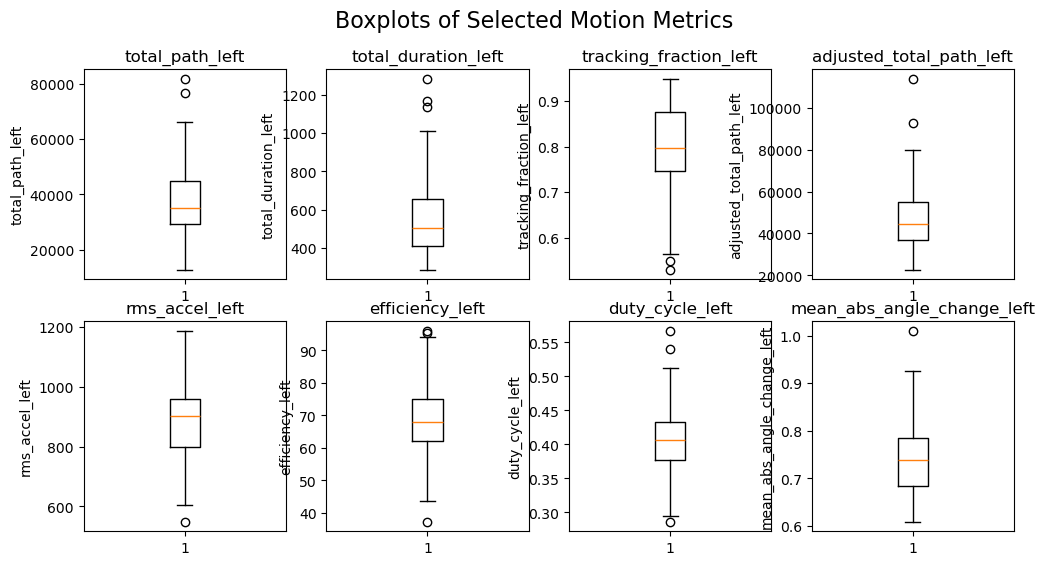

In [7]:

# Left-hand plot
left_metrics = [c for c in df_metrics.columns if c.endswith("_left")]
left_corr = {k: v for k, v in correlations.items() if k in left_metrics}
plot_metric_correlations(left_corr, title="Left Hand Metrics vs GRS")

# Right-hand plot
right_metrics = [c for c in df_metrics.columns if c.endswith("_right")]
right_corr = {k: v for k, v in correlations.items() if k in right_metrics}
plot_metric_correlations(right_corr, title="Right Hand Metrics vs GRS")

left_metrics.remove('tremor_rms_left')
left_metrics.remove('mean_velocity_left')
right_metrics.remove('tremor_rms_right')
right_metrics.remove('mean_velocity_right')
boxplot_metrics(df_metrics, left_metrics)
boxplot_metrics(df_metrics, right_metrics)

In [22]:
df_pairwise_corr_l, _ = correlated_metrics(
    df_metrics[left_metrics], 
    left_corr, 
    threshold=0.3
)

df_pairwise_corr_r, _ = correlated_metrics(
    df_metrics[right_metrics], 
    right_corr, 
    threshold=0.3
)

print("Left Hand Pairwise Correlations:\n", df_pairwise_corr_l, "\n")
print("Right Hand Pairwise Correlations:\n", df_pairwise_corr_r)

Left Hand Pairwise Correlations:
                      total_path_left  total_duration_left  rms_accel_left  \
total_path_left             1.000000             0.838266       -0.172541   
total_duration_left         0.838266             1.000000       -0.524732   
rms_accel_left             -0.172541            -0.524732        1.000000   
efficiency_left             0.118988            -0.401020        0.727771   
num_reversals_left          0.952911             0.879261       -0.315344   

                     efficiency_left  num_reversals_left  
total_path_left             0.118988            0.952911  
total_duration_left        -0.401020            0.879261  
rms_accel_left              0.727771           -0.315344  
efficiency_left             1.000000           -0.043646  
num_reversals_left         -0.043646            1.000000   

Right Hand Pairwise Correlations:
                              total_path_right  total_duration_right  \
total_path_right                     1.00

In [23]:
df_pairwise_corr, selected_metrics = correlated_metrics(
    df_metrics, 
    correlations, 
    threshold=0.3
)
df_pairwise_corr

,total_path_left,total_duration_left,rms_accel_left,efficiency_left,num_reversals_left,total_path_right,total_duration_right,duty_cycle_right,mean_abs_angle_change_right,num_reversals_right
total_path_left,1.000000,0.838266,-0.172541,0.118988,0.952911,0.786168,0.835235,0.196710,-0.383321,0.807626
total_duration_left,0.838266,1.000000,-0.524732,-0.401020,0.879261,0.878218,0.999753,0.197261,-0.477638,0.930049
rms_accel_left,-0.172541,-0.524732,1.000000,0.727771,-0.315344,-0.432796,-0.526147,0.075388,0.254238,-0.425302
efficiency_left,0.118988,-0.401020,0.727771,1.000000,-0.043646,-0.288883,-0.408048,0.023051,0.262837,-0.323053
num_reversals_left,0.952911,0.879261,-0.315344,-0.043646,1.000000,0.852297,0.877468,0.228118,-0.436031,0.858341
total_path_right,0.786168,0.878218,-0.432796,-0.288883,0.852297,1.000000,0.879801,0.505714,-0.388321,0.953281
total_duration_right,0.835235,0.999753,-0.526147,-0.408048,0.877468,0.879801,1.000000,0.198609,-0.481064,0.930649
duty_cycle_right,0.196710,0.197261,0.075388,0.023051,0.228118,0.505714,0.198609,1.000000,-0.041955,0.487518
mean_abs_angle_change_right,-0.383321,-0.477638,0.254238,0.262837,-0.436031,-0.388321,-0.481064,-0.041955,1.000000,-0.421332
num_reversals_right,0.807626,0.930049,-0.425302,-0.323053,0.858341,0.953281,0.930649,0.487518,-0.421332,1.000000


100%|██████████| 86/86 [00:35<00:00,  2.45it/s]


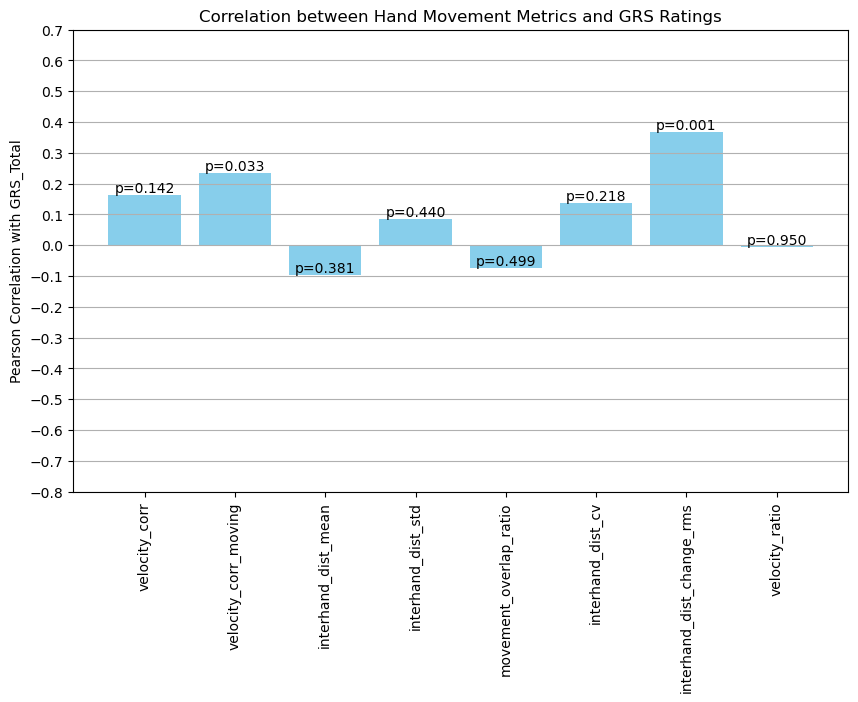

In [19]:
df_bimanual_metrics, correlations_bimanual = analyze_metrics_vs_grs(
    processed_dir="processed_dataframes",
    ratings_csv="merged_scores.csv",
    metric_func=compute_bimanual_dexterity,
    fps=30,
    correlation="spearman",
    score_col='QRS_Overal',
    end = "10fps_processed.pkl"
)

# make a bar plot of the correlations with the p_values diplayed on top
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(correlations_bimanual.keys(), [v["correlation"] for v in correlations_bimanual.values()],
        color='skyblue')
plt.ylabel("Pearson Correlation with GRS_Total")
plt.title("Correlation between Hand Movement Metrics and GRS Ratings")
for i, (col, vals) in enumerate(correlations_bimanual.items()):
    plt.text(i, vals["correlation"], f'p={vals["p_value"]:.3f}', ha='center', va='bottom')
# vertical x-axis labels
plt.xticks(rotation=90)
plt.grid(axis='y')
# more y-axis ticks
plt.yticks(np.arange(-0.8, 0.8, 0.1))
plt.show()

  0%|          | 0/86 [00:00<?, ?it/s]

100%|██████████| 86/86 [02:07<00:00,  1.48s/it]


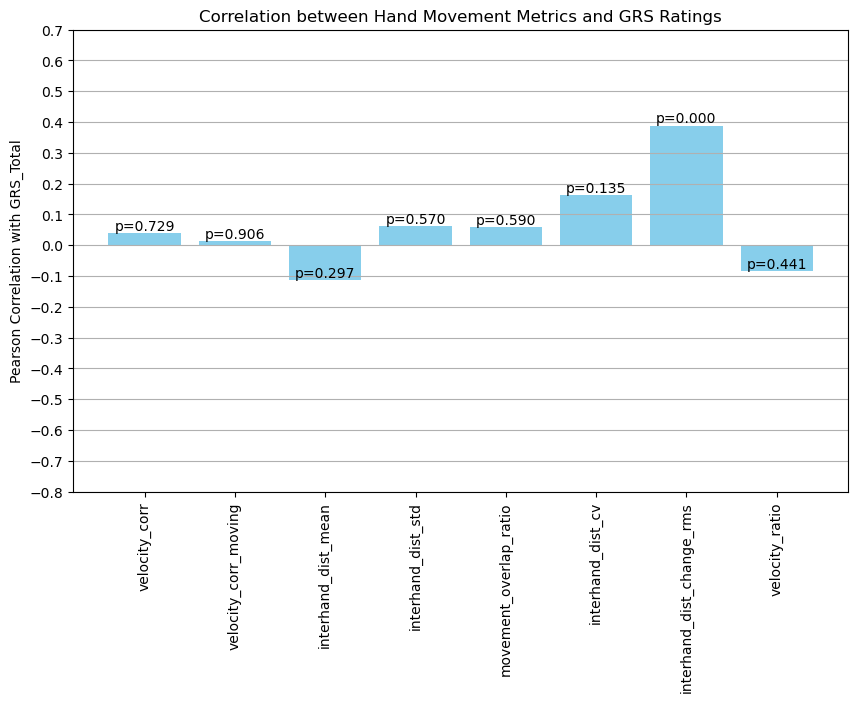

In [10]:
df_bimanual_metrics, correlations_bimanual = analyze_metrics_vs_grs(
    processed_dir="processed_dataframes",
    ratings_csv="averaged_ratings.csv",
    metric_func=compute_bimanual_dexterity,
    fps=30,
    correlation="spearman",
    end = "30fps_processed.pkl"
)

# make a bar plot of the correlations with the p_values diplayed on top
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(correlations_bimanual.keys(), [v["correlation"] for v in correlations_bimanual.values()],
        color='skyblue')
plt.ylabel("Pearson Correlation with GRS_Total")
plt.title("Correlation between Hand Movement Metrics and GRS Ratings")
for i, (col, vals) in enumerate(correlations_bimanual.items()):
    plt.text(i, vals["correlation"], f'p={vals["p_value"]:.3f}', ha='center', va='bottom')
# vertical x-axis labels
plt.xticks(rotation=90)
plt.grid(axis='y')
# more y-axis ticks
plt.yticks(np.arange(-0.8, 0.8, 0.1))
plt.show()

## Fit a Linear Mixed Effects Model to the Data

1. Using all the left and right hand predictors seperately

2. Using combined predictors

In [32]:
df_metrics

,Participant Number,Age,Gender,Case_Number,Experience_Total,Position,GRS_Total,OSATS_Total,CFS_Total,Self_Rating,...,total_duration_right,mean_velocity_right,rms_accel_right,efficiency_right,duty_cycle_right,tremor_rms_right,mean_abs_angle_change_right,num_reversals_right,intermittency_ratio_right,file
0,1,28,m,1,2.0,Assistenzarzt/Assistenzärztin,59.25,23.00,9.25,3.0,...,534.933333,100.941580,1160.203584,79.625121,0.595775,0.000000,0.769685,741,0.159839,hand_tracking_2024-01-15_13-18-23processed.pkl
1,1,28,m,2,2.0,Assistenzarzt/Assistenzärztin,54.40,24.60,10.80,4.0,...,287.833333,97.485435,1114.999727,78.732862,0.538506,0.000000,0.947384,382,0.169047,hand_tracking_2024-01-15_13-37-36processed.pkl
2,1,28,m,3,2.0,Assistenzarzt/Assistenzärztin,74.50,30.00,9.50,4.0,...,423.033333,107.876550,964.370820,95.582644,0.682452,0.000000,0.952774,697,0.115522,hand_tracking_2024-01-15_14-03-23processed.pkl
3,2,28,m,1,3.0,Assistenzarzt/Assistenzärztin,49.25,19.50,9.50,1.0,...,1281.533333,76.023448,669.504993,61.251729,0.608256,1.344498,0.744840,1613,0.178547,hand_tracking_2024-01-15_14-32-45processed.pkl
4,2,28,m,2,3.0,Assistenzarzt/Assistenzärztin,49.00,16.50,8.00,1.0,...,1010.833333,70.222350,661.494212,62.295158,0.591195,0.000000,0.734362,1155,0.182620,hand_tracking_2024-01-15_15-05-31processed.pkl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,28,31,m,2,4.0,Assistenzarzt/Assistenzärztin,72.25,35.25,12.25,5.0,...,329.833333,79.007771,844.080994,60.092527,0.513896,2.148084,0.835796,351,0.195091,hand_tracking_2024-01-24_16-04-43processed.pkl
82,28,31,m,3,4.0,Assistenzarzt/Assistenzärztin,70.00,28.25,9.75,5.0,...,354.933333,105.559334,865.279897,86.077629,0.583490,0.000000,0.871580,452,0.119398,hand_tracking_2024-01-24_16-21-06processed.pkl
83,29,24,w,1,0.0,Unterassistenzarzt/Unterassistenzärztin,49.75,18.00,10.50,4.0,...,693.733333,105.941307,990.844635,88.845759,0.625024,0.469781,0.756963,988,0.175448,hand_tracking_2024-01-24_16-52-58processed.pkl
84,29,24,w,2,0.0,Unterassistenzarzt/Unterassistenzärztin,62.00,32.75,10.50,2.0,...,590.333333,91.421770,822.192336,81.327067,0.605590,1.202995,0.758572,757,0.179236,hand_tracking_2024-01-24_17-19-03processed.pkl


In [38]:
import statsmodels.formula.api as smf


model = smf.mixedlm("GRS_Total ~ total_path_left + total_duration_left + mean_velocity_left + rms_accel_left + efficiency_left + duty_cycle_left + mean_abs_angle_change_left + num_reversals_left + intermittency_ratio_left" \
" + total_path_right + total_duration_right + mean_velocity_right + mean_velocity_right + rms_accel_right + efficiency_right + duty_cycle_right + mean_abs_angle_change_right + num_reversals_right + intermittency_ratio_right",
 df_metrics, groups=df_metrics["Participant Number"])

results = model.fit()
print(results.summary())

                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       GRS_Total
No. Observations:        86            Method:                   REML     
No. Groups:              29            Scale:                    34.8608  
Min. group size:         2             Log-Likelihood:           -298.6616
Max. group size:         3             Converged:                Yes      
Mean group size:         3.0                                              
--------------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
--------------------------------------------------------------------------
Intercept                    57.736   30.116  1.917 0.055   -1.291 116.763
total_path_left               0.000    0.000  0.561 0.575   -0.001   0.001
total_duration_left          -0.131    0.196 -0.671 0.502   -0.515   0.252
mean_velocity_left            0.263    0.157

In [75]:
X = df_metrics[[col for col in df_metrics.columns if 'left' in col or 'right' in col]].drop(columns=['tremor_rms_left', 'tremor_rms_right'])
X = df_metrics[[col for col in df_metrics.columns if 'right' in col]].drop(columns=['tremor_rms_right'])
X = X.join(df_bimanual_metrics[['interhand_dist_change_rms']])

# standarize metrics before regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [461]:
import statsmodels.formula.api as smf

df_scaled = pd.concat([df_metrics[["GRS_Total", "Participant Number"]], X_scaled], axis=1)

model = smf.mixedlm("GRS_Total ~ total_path_left + total_duration_left + mean_velocity_left + rms_accel_left + efficiency_left + duty_cycle_left + mean_abs_angle_change_left + num_reversals_left + intermittency_ratio_left + total_path_right + total_duration_right + mean_velocity_right + rms_accel_right + efficiency_right + duty_cycle_right + mean_abs_angle_change_right + num_reversals_right + intermittency_ratio_right" \
                    " + velocity_corr + velocity_corr_moving + interhand_dist_mean + interhand_dist_std + movement_overlap_ratio + interhand_dist_cv + interhand_dist_change_rms + velocity_ratio",
                     df_scaled, groups=df_scaled["Participant Number"])

results = model.fit()
print(results.summary())

PatsyError: Error evaluating factor: NameError: name 'num_reversals_left' is not defined
    GRS_Total ~ total_path_left + total_duration_left + mean_velocity_left + rms_accel_left + efficiency_left + duty_cycle_left + mean_abs_angle_change_left + num_reversals_left + intermittency_ratio_left + total_path_right + total_duration_right + mean_velocity_right + rms_accel_right + efficiency_right + duty_cycle_right + mean_abs_angle_change_right + num_reversals_right + intermittency_ratio_right + velocity_corr + velocity_corr_moving + interhand_dist_mean + interhand_dist_std + movement_overlap_ratio + interhand_dist_cv + interhand_dist_change_rms + velocity_ratio
                                                                                                                                                               ^^^^^^^^^^^^^^^^^^

In [76]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)


# pca.components_ shape: (n_components, n_features)
loadings = pd.DataFrame(pca.components_.T, 
                        index=X_scaled.columns, 
                        columns=[f'PC{i+1}' for i in range(pca.n_components_)])
print(loadings)



                                  PC1       PC2       PC3       PC4       PC5
total_path_right             0.435891  0.192141  0.012073  0.127332 -0.013524
total_duration_right         0.454314 -0.027531 -0.015678  0.270615  0.006885
adjusted_total_path_right    0.423900  0.176629  0.121272  0.260257 -0.077965
mean_velocity_right         -0.127340  0.465673  0.253557  0.017357 -0.143849
rms_accel_right             -0.139510  0.378438  0.490158 -0.071895 -0.163233
efficiency_right            -0.006158  0.507663  0.003133 -0.298663  0.061434
duty_cycle_right             0.147076  0.373875 -0.352648 -0.438134  0.395275
mean_abs_angle_change_right -0.287795  0.184939 -0.337240  0.414748  0.547204
num_reversals_right          0.447460  0.138477 -0.085746  0.125329  0.073355
intermittency_ratio_right    0.115059 -0.234808  0.649423 -0.107011  0.690649
interhand_dist_change_rms   -0.265092  0.255032  0.114681  0.597507  0.067287


In [77]:
# what percentage of variance is explained by each component
pca.explained_variance_ratio_


array([0.40581118, 0.31708149, 0.1122687 , 0.07559042, 0.04085218])

In [40]:
import statsmodels.formula.api as smf
X_PCA = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3", "PC4", "PC5"])
df_PCA = pd.concat([df_metrics[["GRS_Total", "Participant Number", "Case_Number"]], X_PCA], axis=1)

model = smf.mixedlm("GRS_Total ~ PC1 + PC2 + PC3 + C(Case_Number)",
 df_PCA, groups=df_PCA["Participant Number"])
results = model.fit()
print(results.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   GRS_Total
No. Observations:    86        Method:               REML     
No. Groups:          29        Scale:                31.3673  
Min. group size:     2         Log-Likelihood:       -282.1645
Max. group size:     3         Converged:            Yes      
Mean group size:     3.0                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           60.091    1.539 39.034 0.000 57.074 63.108
C(Case_Number)[T.2]  1.065    1.778  0.599 0.549 -2.420  4.550
C(Case_Number)[T.3]  4.587    2.150  2.134 0.033  0.374  8.801
PC1                 -1.509    0.678 -2.225 0.026 -2.839 -0.180
PC2                 -2.509    0.580 -4.324 0.000 -3.646 -1.372
PC3                 -1.196    0.838 -1.427 0.153 -2.839  0.446
Group

In [131]:
df_metrics0

,Participant Number,Age,Gender,Case_Number,Experience_Total,Position,GRS_Total,OSATS_Total,CFS_Total,Self_Rating,...,tremor_energy_left,duty_cycle_left,total_path_right,mean_speed_right,std_speed_right,rms_accel_right,rms_jerk_right,tremor_energy_right,duty_cycle_right,file
0,1,28,m,1,2.0,Assistenzarzt/Assistenzärztin,59.25,23.00,9.25,3.0,...,8020.948952,0.443120,42594.131164,100.941580,171.369256,1160.203584,16209.265499,8353.881559,0.595812,hand_tracking_2024-01-15_13-18-23processed.pkl
1,1,28,m,2,2.0,Assistenzarzt/Assistenzärztin,54.40,24.60,10.80,4.0,...,21201.538715,0.436067,22661.942138,97.485435,170.268139,1114.999727,15936.190204,9679.627571,0.538568,hand_tracking_2024-01-15_13-37-36processed.pkl
2,1,28,m,3,2.0,Assistenzarzt/Assistenzärztin,74.50,30.00,9.50,4.0,...,8865.243055,0.556396,40434.644477,107.876550,162.522425,964.370820,13746.005914,7317.773902,0.682506,hand_tracking_2024-01-15_14-03-23processed.pkl
3,2,28,m,1,3.0,Assistenzarzt/Assistenzärztin,49.25,19.50,9.50,1.0,...,4488.164720,0.336089,78496.132023,76.023448,112.133029,669.504993,9047.909659,3212.359852,0.608272,hand_tracking_2024-01-15_14-32-45processed.pkl
4,2,28,m,2,3.0,Assistenzarzt/Assistenzärztin,49.00,16.50,8.00,1.0,...,5418.381350,0.412760,62970.022380,70.222350,115.859087,661.494212,8667.124321,3299.516042,0.591215,hand_tracking_2024-01-15_15-05-31processed.pkl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,28,31,m,2,4.0,Assistenzarzt/Assistenzärztin,72.25,35.25,12.25,5.0,...,7564.231091,0.420321,19820.518370,79.007771,143.880417,844.080994,11872.535523,4703.397747,0.513948,hand_tracking_2024-01-24_16-04-43processed.pkl
82,28,31,m,3,4.0,Assistenzarzt/Assistenzärztin,70.00,28.25,9.75,5.0,...,9057.441497,0.420445,30551.819931,105.559334,150.304376,865.279897,12037.590879,5017.322106,0.583545,hand_tracking_2024-01-24_16-21-06processed.pkl
83,29,24,w,1,0.0,Unterassistenzarzt/Unterassistenzärztin,49.75,18.00,10.50,4.0,...,10107.964093,0.508003,61635.264796,105.941307,166.041897,990.844635,13622.725276,8537.908211,0.625054,hand_tracking_2024-01-24_16-52-58processed.pkl
84,29,24,w,2,0.0,Unterassistenzarzt/Unterassistenzärztin,62.00,32.75,10.50,2.0,...,11118.457575,0.361088,48010.078704,91.421770,146.729987,822.192336,11273.142188,5116.811981,0.605624,hand_tracking_2024-01-24_17-19-03processed.pkl


In [166]:
# standarize metrics before regression
X = df_bimanual_metrics[[col for col in correlations_bimanual.keys()]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled = pd.concat([df_bimanual_metrics[["GRS_Total", "Participant Number"]], X_scaled], axis=1)

# pca 
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)

# mixed effects model with the first 2 principal components
# X_PCA = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3", "PC4", "PC5"])
# df_PCA = pd.concat([df_bimanual_metrics[["GRS_Total", "Participant Number"]], X_PCA], axis=1)

model = smf.mixedlm("GRS_Total ~ velocity_corr + velocity_corr_moving + interhand_dist_mean + interhand_dist_std + movement_overlap_ratio + interhand_dist_cv + interhand_dist_change_rms + velocity_ratio",
 df_scaled, groups=df_scaled["Participant Number"])
results = model.fit()
print(results.summary())



[0.35546303 0.31471259 0.10792314 0.0856902  0.07672778]
                Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      GRS_Total
No. Observations:      86           Method:                  REML     
No. Groups:            29           Scale:                   32.5968  
Min. group size:       2            Log-Likelihood:          -286.9594
Max. group size:       3            Converged:               Yes      
Mean group size:       3.0                                            
----------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
----------------------------------------------------------------------
Intercept                  61.875    1.757 35.207 0.000  58.431 65.320
velocity_corr              -0.235    1.587 -0.148 0.882  -3.345  2.875
velocity_corr_moving       -0.954    1.487 -0.642 0.521  -3.868  1.960
interhand_dist_mean        -9.526    

# Cross validation

LOOCV MAE: 5.91 vs Naive MAE: 9.06
LOOCV RMSE: 7.39 vs Naive RMSE: 10.67
LOOCV SD: 7.39 vs Naive SD: 10.67
LOOCV Correlation: 0.72


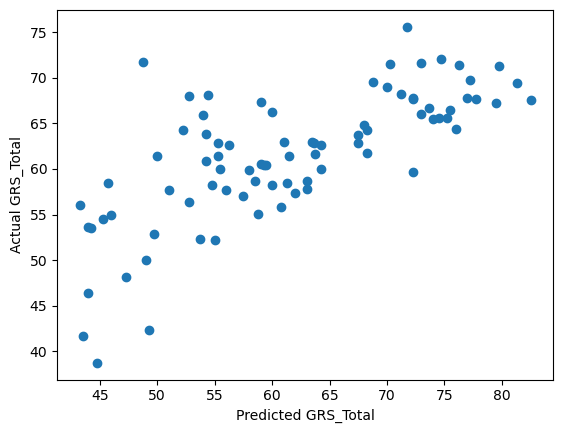

In [23]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Assume df_metrics has Participant Number and left/right metrics
left_right_metrics = [col for col in df_metrics.columns if 'right' in col]# or 'left' in col]
#left_right_metrics = ['total_path_right', 'total_duration_right', 'num_reversals_right', 'mean_abs_angle_change_right',]
#left_right_metrics.remove('tremor_rms_left')
left_right_metrics.remove('tremor_rms_right')
#left_right_metrics.extend(['interhand_dist_change_rms'])
#df_metrics = df_metrics.join(df_bimanual_metrics[['interhand_dist_change_rms']])

#left_right_metrics = ['velocity_corr', 'velocity_corr_moving', 'interhand_dist_mean', 'interhand_dist_std', 'movement_overlap_ratio', 'interhand_dist_cv', 'interhand_dist_change_rms', 'velocity_ratio']
# velocity_corr + velocity_corr_moving + interhand_dist_mean + interhand_dist_std + movement_overlap_ratio + interhand_dist_cv + interhand_dist_change_rms + velocity_ratio
#df_metrics = df_bimanual_metrics

sm_string = " + ".join(left_right_metrics)
#left_right_metrics = ['total_path_right', 'total_duration_right', 'num_reversals_right', 'mean_abs_angle_change_right']

# scale the metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_metrics[left_right_metrics])
X_scaled = pd.DataFrame(X_scaled, columns=left_right_metrics)
df_metrics_scaled = pd.concat([df_metrics[['Participant Number', 'GRS_Total']], X_scaled], axis=1)

# Step 1: Compute PCs
pca = PCA(n_components=5)
X_pcs = pca.fit_transform(df_metrics_scaled[left_right_metrics])

# Add PCs to dataframe
for i in range(5):
    df_metrics[f'PC{i+1}'] = X_pcs[:, i]

# Step 2: LOOCV
participants = df_metrics['Participant Number'].unique()
y_true = []
y_pred = []

for p in participants:
    # Train/test split
    train_df = df_metrics[df_metrics['Participant Number'] != p]
    test_df = df_metrics[df_metrics['Participant Number'] == p]
    
    # Fit LME with PCs as fixed effects, participant as random effect
    model = smf.mixedlm(
        f"GRS_Total ~ PC1 + PC2 + PC3",
        train_df,
        groups=train_df["Participant Number"]
    )
    results = model.fit()
    
    # Predict for left-out participant
    pred = results.predict(test_df)
    
    y_true.extend(test_df['GRS_Total'].values)
    y_pred.extend(pred.values)

# Step 3: Compute performance metrics
y_true = np.array(y_true)
y_pred = np.array(y_pred)
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
sd = np.std(y_pred - y_true)
corr = np.corrcoef(y_true, y_pred)[0,1]

# compare to a naive mean predictor
mean_pred = np.mean(df_metrics['GRS_Total'])
naive_mae = np.mean(np.abs(y_true - mean_pred))
naive_rmse = np.sqrt(np.mean((y_true - mean_pred)**2)) 
naive_sd = np.std(mean_pred - y_true)

print(f"LOOCV MAE: {mae:.2f} vs Naive MAE: {naive_mae:.2f}")
print(f"LOOCV RMSE: {rmse:.2f} vs Naive RMSE: {naive_rmse:.2f}")
print(f"LOOCV SD: {sd:.2f} vs Naive SD: {naive_sd:.2f}")
print(f"LOOCV Correlation: {corr:.2f}")

# Plot the predicted scores agains that actual scores
plt.plot(y_true, y_pred, 'o')
plt.xlabel("Predicted GRS_Total")
plt.ylabel("Actual GRS_Total")
plt.show()


/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/finnweikert/opt/anaconda3/envs/Project/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is 

Worst prediction for Participant 14, Case 2 with error 10.55  (True: 66.25, Predicted: 55.70)
Worst prediction for Participant 3, Case 1 with error 10.69  (True: 62.00, Predicted: 51.31)
Worst prediction for Participant 2, Case 1 with error 10.75  (True: 39.25, Predicted: 28.50)
Worst prediction for Participant 18, Case 2 with error 11.24  (True: 35.50, Predicted: 46.74)
Worst prediction for Participant 19, Case 2 with error 11.28  (True: 33.75, Predicted: 45.03)
Worst prediction for Participant 1, Case 2 with error 12.83  (True: 45.00, Predicted: 57.83)
Worst prediction for Participant 14, Case 3 with error 12.85  (True: 67.75, Predicted: 54.90)
Worst prediction for Participant 16, Case 3 with error 13.19  (True: 58.75, Predicted: 45.56)
Worst prediction for Participant 7, Case 3 with error 15.20  (True: 41.25, Predicted: 56.45)
Worst prediction for Participant 21, Case 2 with error 22.65  (True: 38.25, Predicted: 60.90)
LOOCV MAE: 5.21 vs Naive MAE: 7.81
LOOCV SD: 6.69 vs Naive SD: 9

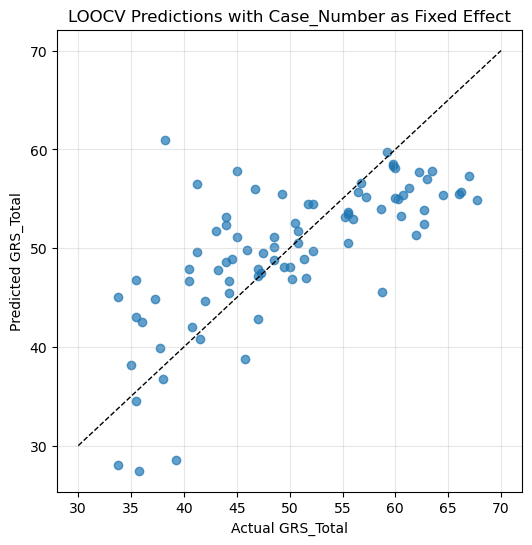

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- Step 1: Prepare metrics ---
metrics = [col for col in df_metrics.columns if 'right' in col]# or 'left' in col]
if 'tremor_rms_right' in metrics:
    metrics.remove('tremor_rms_right')
if 'tremor_rms_left' in metrics:
    metrics.remove('tremor_rms_left')
metrics = ["total_path_right", "total_duration_right", "num_reversals_right", "mean_abs_angle_change_right"]
#metrics.extend(['interhand_dist_change_rms'])

# Standardize metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_metrics[metrics])
X_scaled = pd.DataFrame(X_scaled, columns=metrics)
df_metrics_scaled = pd.concat([df_metrics[['Participant Number', 'GRS_Total', 'QRS_Overal', 'Case_Number']], X_scaled], axis=1)
#df_metrics_scaled['adjusted_total_path_right'] = df_metrics_scaled['total_path_right']*df_metrics['tracking_fraction_right']  # keep unscaled for reference
#df_metrics_scaled['adjusted_total_path_left'] = df_metrics_scaled['total_path_left']*df_metrics['tracking_fraction_left']  # keep unscaled for reference
#df_metrics_scaled.drop(columns=['total_path_right', 'tracking_fraction_right'], inplace=True)
#metrics.remove('total_path_right')
#metrics.remove('tracking_fraction_right')
#metrics.append('adjusted_total_path_right')
# --- Step 2: Compute PCA components ---
pca = PCA(n_components=3)
X_pcs = pca.fit_transform(df_metrics_scaled[metrics])

for i in range(3):
    df_metrics_scaled[f'PC{i+1}'] = X_pcs[:, i]

# --- Step 3: LOOCV setup ---
participants = df_metrics_scaled['Participant Number'].unique()
y_true = []
y_pred = []
case_number = []

for p in participants:
    train_df = df_metrics_scaled[df_metrics_scaled['Participant Number'] != p]
    test_df = df_metrics_scaled[df_metrics_scaled['Participant Number'] == p]

    # keep track of the file

    # --- Step 4: Mixed Linear Model with Case_Number as fixed effect ---
    model = smf.mixedlm(
        f"QRS_Overal ~ PC1 + PC2 + PC3",
        train_df,
        groups=train_df["Participant Number"],
        vc_formula={"Case": "0 + C(Case_Number)"}
    )
    results = model.fit()

    # Predict for the left-out participant
    pred = results.predict(test_df)
    y_true.extend(test_df['QRS_Overal'].values)
    y_pred.extend(pred.values)
    case_number.extend(test_df['Case_Number'].values)

# --- Step 5: Evaluate performance ---
y_true = np.array(y_true)
y_pred = np.array(y_pred)

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
sd = np.std(y_pred - y_true)
corr = np.corrcoef(y_true, y_pred)[0, 1]

# --- Identify worst prediction ---
errors = np.abs(y_true - y_pred)
# worst 10 predictions
worst_indices = np.argsort(errors)[-10:]
worst_participants = df_metrics_scaled.iloc[worst_indices][['Participant Number', 'Case_Number']]
for worst_idx in worst_indices:
    print(f"Worst prediction for Participant {worst_participants.loc[worst_idx, 'Participant Number']}, Case {worst_participants.loc[worst_idx, 'Case_Number']} with error {errors[worst_idx]:.2f}",
          f" (True: {y_true[worst_idx]:.2f}, Predicted: {y_pred[worst_idx]:.2f})")

# Naive mean predictor but per case number
mean_pred_case_1 = np.mean(df_metrics_scaled[df_metrics_scaled['Case_Number'] == 1]['QRS_Overal'])
mean_pred_case_2 = np.mean(df_metrics_scaled[df_metrics_scaled['Case_Number'] == 2]['QRS_Overal'])
mean_pred_case_3 = np.mean(df_metrics_scaled[df_metrics_scaled['Case_Number'] == 3]['QRS_Overal'])

mean_case_preds = [mean_pred_case_1, mean_pred_case_2, mean_pred_case_3]
naive_case_preds = [mean_case_preds[cn-1] for cn in case_number]
naive_mae = np.mean(np.abs(y_true - naive_case_preds))
naive_sd = np.std(np.array(naive_case_preds) - y_true)

print(f"LOOCV MAE: {mae:.2f} vs Naive MAE: {naive_mae:.2f}")
print(f"LOOCV SD: {sd:.2f} vs Naive SD: {naive_sd:.2f}")
print(f"LOOCV Correlation: {corr:.2f}")

# --- Step 6: Visualization ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([30, 70], [30, 70], 'k--', lw=1)
plt.xlabel("Actual GRS_Total")
plt.ylabel("Predicted GRS_Total")
plt.title("LOOCV Predictions with Case_Number as Fixed Effect")
plt.grid(True, alpha=0.3)
plt.show()



In [44]:
df_metrics_scaled

,Participant Number,GRS_Total,Case_Number,total_path_right,total_duration_right,mean_velocity_right,rms_accel_right,efficiency_right,duty_cycle_right,mean_abs_angle_change_right,num_reversals_right,intermittency_ratio_right,interhand_dist_change_rms,PC1,PC2,PC3,PC4,PC5
0,1,59.25,1,-0.084272,-0.162024,0.421723,0.046321,0.138956,0.530460,-0.910719,0.009453,-0.414469,0.180845,-0.137249,0.464043,0.067855,-0.529745,-0.618210
1,1,54.40,2,-1.395132,-1.357591,-0.238568,0.462153,-0.353732,-0.410339,0.115065,-1.175970,0.704708,-0.199038,-1.183613,-1.815754,0.684385,-0.919403,0.388167
2,1,74.50,3,-0.209091,-0.703440,0.803621,-0.009312,1.462991,1.944141,1.425246,-0.112312,-1.892517,0.826954,-2.335583,1.818260,-2.053304,-0.435692,0.317931
3,2,49.25,1,2.332379,3.450320,-1.308878,-1.996100,-1.131230,0.559589,-1.108215,3.200425,0.867561,-1.903646,5.948480,1.694333,-0.723603,0.951646,0.500030
4,2,49.00,2,1.357102,2.140567,-1.769814,-1.708812,-1.018013,0.565054,-1.053797,1.685519,0.717935,-2.014891,4.607386,0.359828,-0.784210,-0.192368,0.500155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,28,72.25,2,-1.427164,-1.154379,-1.038201,-0.593723,-1.246863,-0.951287,0.381447,-1.286991,2.097598,-0.214619,-0.077390,-3.211443,0.892528,-0.352544,1.489429
82,28,70.00,3,-0.828356,-1.029064,0.575997,0.182579,0.623170,0.244602,0.386441,-0.925276,-1.718580,-0.131258,-1.887348,-0.082958,-1.088868,-0.946111,-0.887834
83,29,49.75,1,1.194571,0.606313,0.798857,0.323182,1.108096,0.946010,-1.027518,1.087436,-0.074060,0.838720,0.337526,2.421437,0.538074,0.234858,-0.363434
84,29,62.00,2,0.322424,0.106023,-0.186265,-0.281027,0.447283,0.936214,-0.530969,0.338936,0.715347,0.292401,0.507134,0.707014,0.256718,-0.332539,0.677430
